# Motion control — PID isolation on the bench (sine / square setpoints)

Drives the wheels with **direct velocity setpoints** — sine and square
waves at several periods — and plots **commanded vs measured** wheel
velocity. Bench only; **robot on the stand, wheels off the ground**
(`.claude/rules/hardware-bench-testing.md`).

## Why: planner or PID?

Turn traces show wobble/raggedness. Two suspects sit in series:

1. the **motion planner** (`Motion::SegmentExecutor` — Ruckig profiles +
   divergence replans), and
2. the **velocity PID** (`Hal::MotorVelocityPid` + the Nezha plant).

This notebook removes suspect 1 entirely: the wire `drive` arm
(`DrivetrainCommand{wheels}`, the `S` verb) is an **escape hatch** — it
clears the segment ring, leaves segment mode, and feeds per-wheel velocity
setpoints straight to the PID. No profile, no replans. Telemetry
(`cmd=`/`vel=`/`ts=`) flows unconditionally as always, so the wire `cmd=`
also verifies what actually reached the PID.

**Read the plots like this:** if the measured velocity tracks these raw
setpoint waveforms crisply (fast rise, small lag, no wobble), the PID+plant
are healthy and the turn raggedness lives in the planner layer. If the PID
itself is sluggish, over/undershooting, or wobbly here, that is the base
defect and the planner never had a chance.

## Method

- Setpoints are streamed fire-and-forget (armored envelopes via
  `send_fast`, no reply-wait) at a 20 ms cadence, so the commanded waveform
  isn't distorted by round-trip pacing.
- Wheels are driven **opposite-sign** (L = +w, R = −w — a spin pattern):
  stand-safe and it hard-bypasses the ratio governor (which only couples
  same-direction wheels), keeping the loop purely per-wheel PID.
- Waveforms: sine and square, amplitude 250 mm/s, periods 3 s / 1 s /
  0.25 s (≥ the 200 ms floor — the flip-flop samples each wheel every few
  loop passes, so faster commands couldn't even be observed).
- Every run ends with a zero setpoint + verified `STOP`; teardown STOPs in
  a `finally`.

Summary metrics per run: **gain** (measured/commanded amplitude), **delay**
(cross-correlation lag), and for squares **rise time** (10→90%) and
**overshoot**.


In [1]:
import base64
import math
import pathlib
import sys
import time

import numpy as np
import pandas as pd

_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "host" / "robot_radio").is_dir()), None)
if REPO is None:
    REPO = pathlib.Path("/Volumes/Proj/proj/RobotProjects/radio-robot-elite")
sys.path.insert(0, str(REPO / "host"))

OUT_DIR = REPO / "tests" / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Session configuration -------------------------------------------------
PORT = None                  # None = auto-detect (device registry)
MODE = "direct"
AMPLITUDE = 250.0            # [mm/s] sub-plateau, PID linear zone
PERIODS = [3.0, 1.0, 0.25]   # [s] low -> high frequency; floor 0.2s
WAVES = ["sine", "square"]
SEND_DT = 0.02               # [s] setpoint streaming cadence
CYCLES = 3                   # cycles per run (min run 2s, max 9s)
FORCE_RECAPTURE = True

print(f"repo: {REPO}")
print(f"waves: {WAVES}  periods: {PERIODS}s  amplitude: {AMPLITUDE:.0f} mm/s")


repo: /Volumes/Proj/proj/RobotProjects/radio-robot-elite
waves: ['sine', 'square']  periods: [3.0, 1.0, 0.25]s  amplitude: 250 mm/s


In [2]:
# --- Wire plumbing: fire-and-forget drive setpoints + telemetry capture ----
from robot_radio.robot import legacy_verbs
from robot_radio.robot.pb2 import envelope_pb2


def drive_envelope(v):  # [mm/s] L=+v, R=-v (spin pattern, governor-bypassing)
    return legacy_verbs.envelope_for_drive([f"{v:.1f}", f"{-v:.1f}"], {})


def fire(conn, env):
    """Fire-and-forget armored envelope -- no reply wait, so the setpoint
    cadence is owned by the host clock, not round-trips. (The unmatched Ack
    is dropped harmlessly by the reader thread.)"""
    armored = "*B" + base64.b64encode(env.SerializeToString()).decode("ascii")
    conn.send_fast(armored)


def stop_envelope():
    env = envelope_pb2.CommandEnvelope()
    env.stop.SetInParent()
    return env


def ver_envelope():
    env = envelope_pb2.CommandEnvelope()
    env.ver.SetInParent()
    return env


def send_verified(conn, env, tries=4, timeout=800):
    for _ in range(tries):
        r = conn.send_envelope(env, read_timeout=timeout)["reply"]
        if r is not None and r.WhichOneof("body") == "ok":
            return True
        time.sleep(0.25)
    return False


def verified_stop(conn):
    """STOP until fresh telemetry confirms both wheels are still."""
    for _ in range(8):
        conn.send_envelope(stop_envelope(), read_timeout=400)
        vels = []
        t0 = time.monotonic()
        while time.monotonic() - t0 < 0.6:
            for f in conn.drain_binary_tlm():
                if f.tlm.has_vel:
                    vels.append((f.tlm.vel_left, f.tlm.vel_right))
            time.sleep(0.02)
        if vels and abs(vels[-1][0]) < 5 and abs(vels[-1][1]) < 5:
            return True
    return False


def waveform(kind, t, period, amp):  # [mm/s]
    ph = 2.0 * math.pi * t / period
    if kind == "sine":
        return amp * math.sin(ph)
    return amp * (1.0 if math.sin(ph) >= 0.0 else -1.0)


def run_wave(conn, kind, period, amp):
    """Stream one waveform run; return a DataFrame of host-commanded points
    and telemetry frames (cmd= wire setpoint, vel= measured, fw stamps)."""
    duration = max(2.0, min(9.0, CYCLES * period))
    rows = []
    sent = []
    conn.drain_binary_tlm()
    t0 = time.monotonic()
    next_send = 0.0
    while True:
        t = time.monotonic() - t0
        if t >= duration:
            break
        if t >= next_send:
            v = waveform(kind, t, period, amp)
            fire(conn, drive_envelope(v))
            sent.append({"t_host": t, "host_cmd": v})
            next_send += SEND_DT
        for f in conn.drain_binary_tlm():
            tlm = f.tlm
            if not tlm.has_vel:
                continue
            rows.append({
                "t_host": time.monotonic() - t0,
                "cmd_l": tlm.cmd_vel_left, "cmd_r": tlm.cmd_vel_right,
                "vel_l": tlm.vel_left, "vel_r": tlm.vel_right,
                "ts_l": int(tlm.ts_left), "ts_r": int(tlm.ts_right),
                "now_fw": int(tlm.now),
            })
        time.sleep(0.002)
    fire(conn, drive_envelope(0.0))
    time.sleep(0.3)
    assert verified_stop(conn), "could not confirm wheels stopped!"
    time.sleep(0.5)
    return pd.DataFrame(rows), pd.DataFrame(sent)


In [3]:
# --- Drive the bench (once per waveform x period) ---------------------------
from robot_radio.io.serial_conn import SerialConnection
from robot_radio.testgui.transport import find_robot_serial_port

import tomllib
with open(REPO / "pyproject.toml", "rb") as _f:
    WORKSPACE_VERSION = tomllib.load(_f)["project"]["version"]


def _paths(kind, period):
    tag = f"{kind}_{int(period*1000)}ms"
    return (OUT_DIR / f"motion_control_{tag}.csv",
            OUT_DIR / f"motion_control_{tag}_sent.csv")


captures = {}   # (kind, period) -> (frames_df, sent_df)

need = FORCE_RECAPTURE or any(
    not _paths(k, p)[0].exists() for k in WAVES for p in PERIODS)
if not need:
    for k in WAVES:
        for p in PERIODS:
            fp, sp = _paths(k, p)
            captures[(k, p)] = (pd.read_csv(fp), pd.read_csv(sp))
    print("all runs cached -- skipping hardware (FORCE_RECAPTURE=True to re-drive)")
else:
    port = PORT or find_robot_serial_port()
    assert port is not None, "no robot serial port found"
    print(f"robot port: {port}")
    conn = SerialConnection(port=port, mode=MODE)
    info = conn.connect(skip_ping=False)
    assert conn.is_open, f"connect failed: {info}"
    try:
        reply = None
        for _ in range(3):
            reply = conn.send_envelope(ver_envelope(), read_timeout=800)["reply"]
            if reply is not None:
                break
            time.sleep(0.3)
        fw = (reply.id.fw_version
              if reply is not None and reply.WhichOneof("body") == "id" else "?")
        marker = "" if fw == WORKSPACE_VERSION else "  <-- LAGS WORKSPACE (reflash?)"
        print(f"firmware: v{fw}   workspace: v{WORKSPACE_VERSION}{marker}")

        assert send_verified(conn, envelope_pb2.CommandEnvelope(
            stream=envelope_pb2.StreamControl(period=20, binary=True))), "stream arm failed"
        time.sleep(0.3)

        for kind in WAVES:
            for period in PERIODS:
                frames, sent = run_wave(conn, kind, period, AMPLITUDE)
                fp, sp = _paths(kind, period)
                frames.to_csv(fp, index=False)
                sent.to_csv(sp, index=False)
                captures[(kind, period)] = (frames, sent)
                print(f"{kind:6s} T={period:4.2f}s: {len(frames)} frames, "
                      f"{len(sent)} setpoints")
    finally:
        try:
            verified_stop(conn)
        finally:
            conn.disconnect()
            print("[safety] STOP verified; serial closed")


robot port: /dev/cu.usbmodem2121102
firmware: v0.20260711.7   workspace: v0.20260711.8  <-- LAGS WORKSPACE (reflash?)


sine   T=3.00s: 450 frames, 450 setpoints


sine   T=1.00s: 150 frames, 150 setpoints


sine   T=0.25s: 100 frames, 100 setpoints


square T=3.00s: 450 frames, 450 setpoints


square T=1.00s: 150 frames, 150 setpoints


square T=0.25s: 100 frames, 100 setpoints


[safety] STOP verified; serial closed


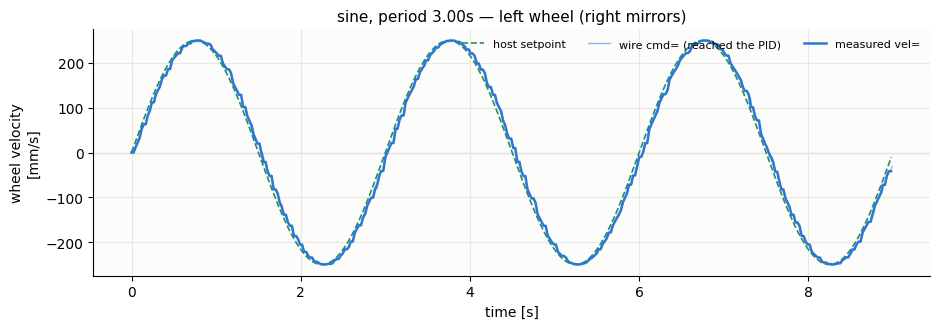

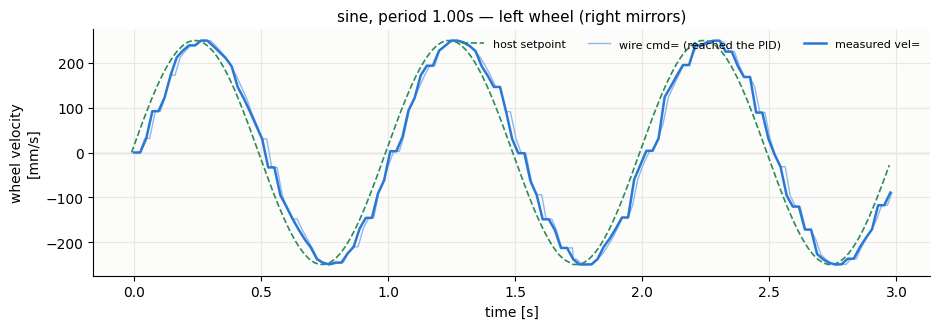

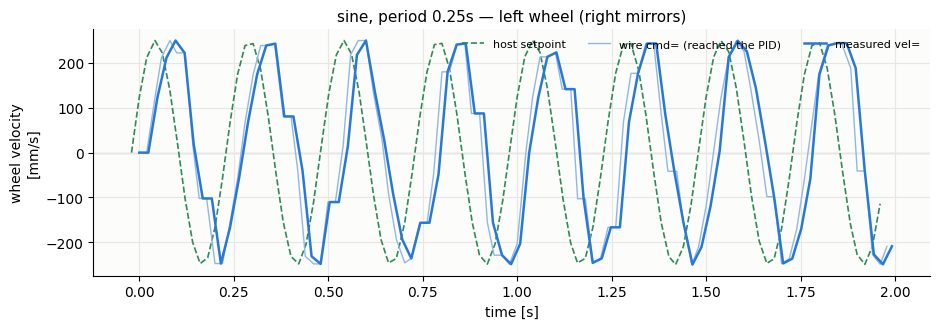

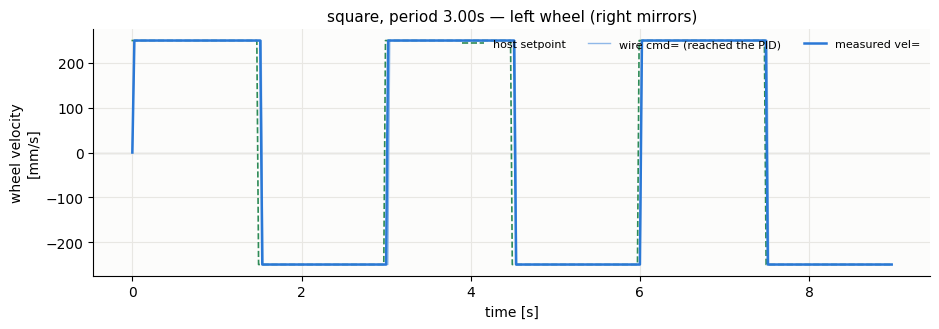

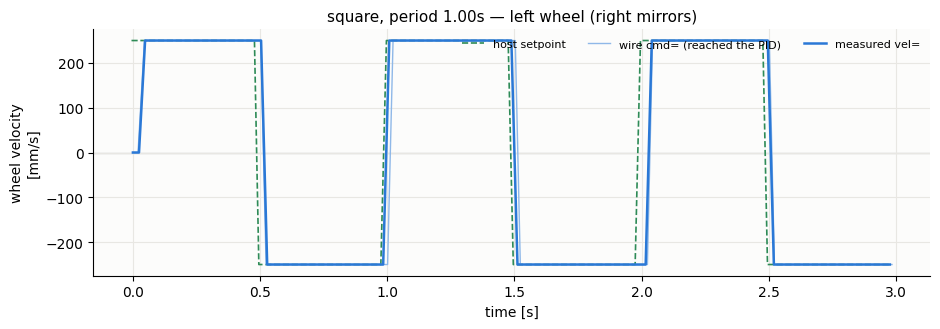

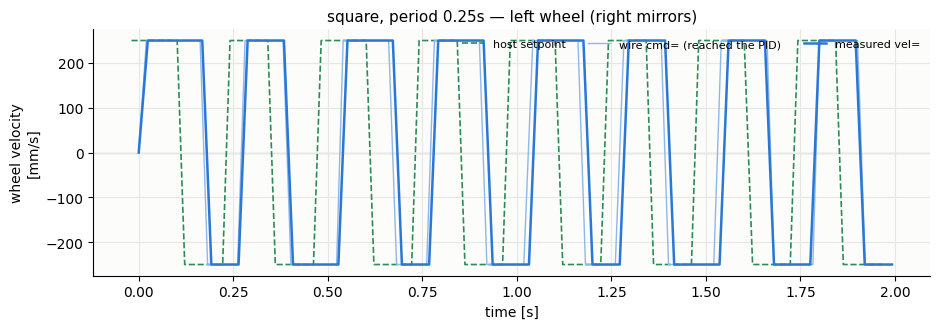

In [4]:
# --- Plots: commanded vs measured, one figure per run ----------------------
# Left wheel only (right is its mirror). Three traces: the HOST waveform
# (what we asked), the WIRE cmd= (what the drivetrain staged for the PID --
# proves delivery), and the MEASURED vel= at each wheel's true firmware
# sample instant (fresh samples only).
import matplotlib.pyplot as plt

HOST = "#2e8b57"
WIRE = "#8fb8e8"
MEAS = "#2a78d6"


def fresh_series(df, val_col, ts_col):
    ts0 = df.loc[df[ts_col] > 0, ts_col].min()
    d = df[df[ts_col] > 0]
    d = d[d[ts_col].diff().fillna(1.0) != 0]
    return (d[ts_col] - ts0) / 1000.0, d[val_col]


def host_time_offset(frames):
    """Map host time onto the firmware axis using the first fresh sample."""
    d = frames[frames["ts_l"] > 0]
    if d.empty:
        return 0.0
    ts0 = d["ts_l"].min()
    row = d.iloc[0]
    return row["t_host"] - (row["ts_l"] - ts0) / 1000.0


def plot_run(kind, period):
    frames, sent = captures.get((kind, period), (None, None))
    if frames is None or frames.empty:
        print(f"{kind} T={period}: no data")
        return
    off = host_time_offset(frames)
    fig, ax = plt.subplots(figsize=(9.5, 3.4), facecolor="white")
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, color="#e8e7e3", lw=0.8, zorder=0)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    ax.plot(sent["t_host"] - off, sent["host_cmd"], color=HOST, lw=1.2,
            ls="--", label="host setpoint")
    x, y = fresh_series(frames, "cmd_l", "ts_l")
    ax.plot(frames["t_host"] - off, frames["cmd_l"], color=WIRE, lw=1.0,
            label="wire cmd= (reached the PID)")
    ax.plot(x, y, color=MEAS, lw=1.8, label="measured vel=")
    ax.set_title(f"{kind}, period {period:.2f}s — left wheel (right mirrors)",
                 fontsize=11)
    ax.set_xlabel("time [s]")
    ax.set_ylabel("wheel velocity\n[mm/s]")
    ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=3)
    fig.tight_layout()
    plt.show()


for kind in WAVES:
    for period in PERIODS:
        plot_run(kind, period)


In [5]:
# --- Summary: gain / delay / (squares) rise time + overshoot ---------------

def analyze(kind, period):
    frames, sent = captures.get((kind, period), (None, None))
    if frames is None or frames.empty:
        return {"wave": kind, "period_s": period, "frames": 0}
    d = frames[frames["ts_l"] > 0]
    d = d[d["ts_l"].diff().fillna(1.0) != 0]
    t = (d["ts_l"].to_numpy() - d["ts_l"].to_numpy()[0]) / 1000.0
    meas = d["vel_l"].to_numpy(dtype=float)
    cmd = d["cmd_l"].to_numpy(dtype=float)
    out = {"wave": kind, "period_s": period, "frames": len(frames)}
    # steady-window: drop the first cycle
    sel = t > period
    if sel.sum() > 10:
        out["gain"] = round(np.std(meas[sel]) / max(1e-6, np.std(cmd[sel])), 3)
    # delay via cross-correlation of cmd vs meas on a uniform grid
    if len(t) > 20:
        tg = np.arange(t[0], t[-1], 0.01)
        ci = np.interp(tg, t, cmd)
        mi = np.interp(tg, t, meas)
        ci -= ci.mean(); mi -= mi.mean()
        lags = np.arange(0, 40)   # 0..400ms
        cc = [np.dot(ci[:len(ci)-k or None], mi[k:]) for k in lags]
        out["delay_ms"] = int(lags[int(np.argmax(cc))] * 10)
    if kind == "square" and sel.sum() > 10:
        # rise time + overshoot on rising edges of the wire cmd
        edges = np.where((cmd[:-1] < 0) & (cmd[1:] > 0))[0]
        rises, overs = [], []
        for e in edges:
            te = t[e + 1]
            w = (t >= te) & (t <= te + min(period / 2, 0.5))
            if w.sum() < 4:
                continue
            seg_t, seg_v = t[w], meas[w]
            a = cmd[e + 1]
            t10 = seg_t[seg_v >= 0.1 * a]
            t90 = seg_t[seg_v >= 0.9 * a]
            if len(t10) and len(t90):
                rises.append(t90[0] - t10[0])
            overs.append((seg_v.max() - a) / a * 100.0)
        if rises:
            out["rise_ms"] = int(np.mean(rises) * 1000)
        if overs:
            out["overshoot_pct"] = round(float(np.mean(overs)), 1)
    return out


pd.DataFrame([analyze(k, p) for k in WAVES for p in PERIODS])


,wave,period_s,frames,gain,delay_ms,rise_ms,overshoot_pct
0,sine,3.00,450,1.094,60,NaN,NaN
1,sine,1.00,150,1.132,70,NaN,NaN
2,sine,0.25,100,0.671,110,NaN,NaN
3,square,3.00,450,1.116,200,71.0,47.9
4,square,1.00,150,1.052,210,60.0,50.0
5,square,0.25,100,0.374,130,0.0,-29.9
